# DigiJazz

Derived from the case study 'DigiJazz' by the NBA [Netherlands Institute of Chartered Accountants](https://www.nba.nl/), in which a fictional company is analyzed based on financial data.

## Introduction

***Evt deze tekst op een aparte slide/handout opnemen ivm leesbaarheid***
***Evt een kortere intro maken. mochten we later analyses toevoegen voor bijv VAT, dan voegen we dat later ook toe.***


### General
DigiJazz is an internationally recognized e-commerce company specializing in the online sale of jazz music. It was founded in 2015 by Dean Mus and Rob Tone. The company provides a 24/7 platform for customers worldwide to download jazz music.

The start-up has been extremely successful and has experienced rapid growth ever since. In 2017, DigiJazz also began selling vinyl records. This was a great success, as many jazz enthusiasts appreciate the nostalgia of vinyl. Consequently, revenue has significantly increased annually since 2018.

The following is a description of the DigiJazz case relevant to the context of the detailed data analysis examples.

### Technical Infrastructure
Sales of online music and vinyl records occur exclusively through the website DigiJazz.nl. Within this web environment, customers can search for, listen to, order, and download their favorite music. Transactions are also recorded and processed in this system.

### Sales Process
DigiJazz has the following revenue categories:
1. Online streaming and downloading of digital jazz music;
2. Sales and delivery of jazz vinyl records.

### Music Streaming and Downloading
To play, download, or purchase music, a customer must first register through the customer registration process. The site allows users to listen to individual tracks or complete albums.

To listen to or download digital music tracks or albums, customers must first purchase credits, which work similarly to a prepaid mobile phone system. After logging in, a customer can purchase credits and make payments. DigiJazz offers online payment options through a Payment Service Provider (PSP).

Once the payment is accepted, the customer's account information and the status of the specific order are updated, allowing the customer to listen to or download the desired item.

### Sales and Delivery of Vinyl Records
Purchases of vinyl records are paid for per transaction and are not processed through the credits system. DigiJazz also provides online payment options via the PSP, and vinyl records are delivered through a courier service.

## The Purchasing Process

### Purchase Contracts for Digital Music and Vinyl Records
Contracts are made with content owners. DigiJazz owes the content owner a fee per track that is listened to or downloaded. The numbers are recorded and reported by DigiJazz. Vinyl records are purchased based on popularity and the personal preferences of the owners.

### Inventory Management
The delivered vinyl records are stored in a warehouse in Beek. Within the warehouse, an inventory administration is maintained. Customers have the right to return ordered vinyl records within the legally defined return period for online purchases. These are received by the warehouse manager and assessed for quality. DigiJazz covers the costs of shipping and any returns. Items that are slightly damaged or cannot be sold as new are stored separately. Records that are broken are classified as obsolete stock and are destroyed.

### VAT
DigiJazz exclusively supplies to private individuals. The sale of digital music is classified for VAT purposes as an electronic service, or e-service. For e-services to private individuals within the EU, there is a special regulation where VAT is due in the member state where the customer resides, according to that country’s rate. In this case, we assume sales are only made to private customers in the Netherlands for the examples in the data analysis.

### General Note Relevant for All Examples
If the auditor identifies an irregularity, they must evaluate whether it indicates a need to revise the risk assessment or if it suggests potential fraud. If there is such an indication of fraud, the auditor must assess the implications of the irregularity for other aspects of the audit. This includes the reliability of management’s representations, considering that a case of fraud is unlikely to be an isolated incident. There may also be human error or a deficiency in the General IT Controls (GITCs), affecting the reliability of the data.

# Data Analysis in Performing Risk Assessment Procedures

An essential principle for performing risk assessment activities is that the auditor gains an understanding of the entity and its environment, including its internal controls (see paragraph 3.3 of NBA Handreiking 1141).

Below are examples of applications from paragraph 3.3 of NBA Guideline 1141. In these two examples, we demonstrate how the outcomes of analyses can provide audit evidence to support risk assessment. These analyses are applied to the example company DigiJazz.

The outcome of the analysis can provide audit evidence to support the assessment of risks. The analysis provides insight into unusual or unexpected correlations that can help the auditor identify risks of material misstatement.

## Our understanding
Management has indicated that typical **digital music sales transactions** have a transaction value of **less than EUR 30**, and that the majority of **vinyl sales transactions** have a transaction value **between EUR 45 and EUR 75**. This aligns with the knowledge the auditor has based on audits from previous years.

## Steps to Conduct the Analysis
* The auditor obtains a download of the XML Auditfile Financial containing all general ledger transactions of the entity;
* The auditor imports the received data into a data analysis tool, such as Excel or Python;
* The auditor validates the reliability of the received data by reconciling it with the trial balance and conducting various data quality checks as indicated below.

In [1]:
# Import the pandas library, refer to Cheatsheet Week 1 - Libraries and Exploring a dataset
import pandas as pd
import os

In [2]:
# Load the data from the Auditfile
gl_df = pd.read_excel(os.path.join(os.getcwd(), "../../GL Generate/transactions.xlsx"), sheet_name="GLData")
gl_df.head(5)

,Date,Period,Description,JournalCode,JournalDesc,JournalType,Booknr,AccountCode,AccountDesc,AccountType,Debit/Credit,Amount,Product ID,User,Relation_id,Relation_name,Account
0,2024-01-01,2024-01,Accrual for Rent - Landlord Inc.,GJ,General Journal,General,GJ069234,4100,Rent Expense,Expense,Debit,1200.0,NaN,NaN,NaN,NaN,4100 Rent Expense
1,2024-01-01,2024-01,Accrual for Rent - Landlord Inc.,GJ,General Journal,General,GJ069234,1950,Accruals Payable,Liability,Credit,1200.0,NaN,NaN,SUPL000001,Landlord Inc.,1950 Accruals Payable
2,2024-01-01,2024-01,Accrual for Water bill - Waternet B.V.,GJ,General Journal,General,GJ069246,4201,Utilities,Expense,Debit,80.0,NaN,NaN,NaN,NaN,4201 Utilities
3,2024-01-01,2024-01,Accrual for Water bill - Waternet B.V.,GJ,General Journal,General,GJ069246,1950,Accruals Payable,Liability,Credit,80.0,NaN,NaN,SUPL000001,Waternet B.V.,1950 Accruals Payable
4,2024-01-01,2024-01,Accrual for Statutory Audit - Tech Audit Firm ...,GJ,General Journal,General,GJ069258,4200,Accounting and Audit Fees,Expense,Debit,10000.0,NaN,NaN,NaN,NaN,4200 Accounting and Audit Fees


In [26]:
# Summarize for quick inspection and reconciliation to general ledger
summary = gl_df[['Account', 'AmountNet']].groupby("Account").sum()
summary

,AmountNet
Account,
1000 Cash,-206002.08
1100 Debtors,0.00
1300 Creditors,0.00
2100 VAT Recoverable,153701.04
2110 VAT Payable,-117948.60
4000 Purchases,731909.64
4100 Rent Expense,14400.00
4200 Accounting and Audit Fees,120000.00
4201 Utilities,960.00


# Chapter 3 - Validating the Reliability of the Data

## Validating the Reliability of the Data based on known rules

In [27]:
# Understand the data we are working with
gl_df.columns

Index(['Unnamed: 0', 'Date', 'Description', 'Journal', 'Account',
       'Debit/Credit', 'Amount', 'Product ID', 'User', 'Relation_id',
       'Relation_name', 'Period', 'AmountNet'],
      dtype='object')

In [ ]:
# Check for missing values
print("Missing values per column:")
print(gl_df.isnull().sum())

In [29]:
# Basic statistics to understand the data distribution
print("\nData summary:")
print(gl_data.describe())


Data summary:
        Unnamed: 0                           Date         Amount   Product ID  \
count  5454.000000                           5454    5454.000000  1000.000000   
mean   2300.940777  2024-06-30 11:21:42.970297088    1349.834455     2.001000   
min       0.000000            2024-01-01 00:00:00      13.650000     1.000000   
25%     909.250000            2024-04-05 00:00:00     121.000000     1.000000   
50%    2272.500000            2024-06-30 00:00:00     242.000000     2.000000   
75%    3635.750000            2024-09-26 00:00:00    1179.750000     3.000000   
max    4999.000000            2025-02-05 00:00:00  120993.700000     3.000000   
std    1531.315411                            NaN    7111.851015     0.820776   

          AmountNet  
count  5.454000e+03  
mean  -5.711440e-15  
min   -1.209937e+05  
25%   -2.420000e+02  
50%   -4.200000e+01  
75%    2.420000e+02  
max    1.209937e+05  
std    7.238841e+03  


In [7]:

# Validate if all data is loaded as expected
print("\nData types:")
print(gl_data.dtypes)

# # Convert columns to appropriate data types
# data['Date'] = pd.to_datetime(data['Date'])
# data['Amount'] = pd.to_numeric(data['Amount'])
# data['AmountNet'] = pd.to_numeric(data['AmountNet'])




Data types:
Unnamed: 0                int64
Date             datetime64[ns]
Description              object
Journal                  object
Account                  object
Debit/Credit             object
Amount                  float64
Product ID              float64
User                     object
Relation_id              object
Relation_name            object
Period                   object
AmountNet               float64
dtype: object


## A GL/Journal matrix

The GL/Journal matrix is a table that shows the Amount per GL account and Journal. This table can be used to quickly identify patterns and anomalies in the data. We can create it easily using Python and Pandas:

In [33]:
# The GL/Journal matrix is a table that shows the Amount per GL account and Journal. This table can be used to quickly identify patterns and anomalies in the data. We can create it easily using Python and Pandas:
# Pivot the data to create a GL/Journal matrix
gl_journal_matrix = gl_df.pivot_table(index='Account', columns='Journal', values='AmountNet', aggfunc='sum').fillna(0)
gl_journal_matrix

Journal,Accruals Journal,Cash Journal,Cash Payments Journal,Purchases Journal,Sales Journal,Sales Journal Projects
Account,,,,,,
1000 Cash,0.0,-206002.08,0.0,0.00,0.00,0.00
1100 Debtors,0.0,-679608.60,0.0,0.00,111785.85,567822.75
1300 Creditors,0.0,885610.68,0.0,-885610.68,0.00,0.00
2100 VAT Recoverable,0.0,0.00,0.0,153701.04,0.00,0.00
2110 VAT Payable,0.0,0.00,0.0,0.00,-19400.85,-98547.75
4000 Purchases,0.0,0.00,0.0,731909.64,0.00,0.00
4100 Rent Expense,14400.0,0.00,0.0,0.00,0.00,0.00
4200 Accounting and Audit Fees,120000.0,0.00,0.0,0.00,0.00,0.00
4201 Utilities,960.0,0.00,0.0,0.00,0.00,0.00


# Data analysis in performing risk assessment activities

An important principle in performing risk assessment activities is that the auditor gains insight into the entity and its environment, including its internal control (see paragraph 3.3 of NBA Handreiking 1141).

Below are two example applications from paragraph 3.3 of NBA Guideline 1141. In these two examples, we show how the results of the analyses can provide audit evidence to support risk assessment. These analyses are applied to our company DigiJazz.

## Selecting sales transactions

In [41]:
# Select data from 'Sales Journal'
sal = gl_df[(gl_df.Journal == 'Sales Journal') & (gl_df.Account.str.contains('8000 Sales'))]
sal.head(4)

,Unnamed: 0,Date,Description,Journal,Account,Debit/Credit,Amount,Product ID,User,Relation_id,Relation_name,Period,AmountNet
1,1,2024-05-18,Sales Order Product B,Sales Journal,8000 Sales,Credit,130.0,2.0,pim_janssen,CUST000001,Michiel Peters,2024-05,-130.0
16,16,2024-04-05,Sales Order Product B,Sales Journal,8000 Sales,Credit,200.0,2.0,MagentoImporter,CUST000004,Peter van den Berg,2024-04,-200.0
21,21,2024-02-24,Sales Order Product B,Sales Journal,8000 Sales,Credit,200.0,2.0,MagentoImporter,CUST000005,Siham Bouchiba,2024-02,-200.0
36,36,2024-01-12,Sales Order Product A,Sales Journal,8000 Sales,Credit,100.0,1.0,MagentoImporter,CUST000008,Menno van der Veen,2024-01,-100.0


## Analyzing sales prices for outliers


Transaction summary by Product ID:
            count        mean        std    min    25%    50%    75%    max
Product ID                                                                 
1.0         336.0   93.229167  13.845777   65.0  100.0  100.0  100.0  100.0
2.0         327.0  186.727829  27.481102  130.0  200.0  200.0  200.0  200.0


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


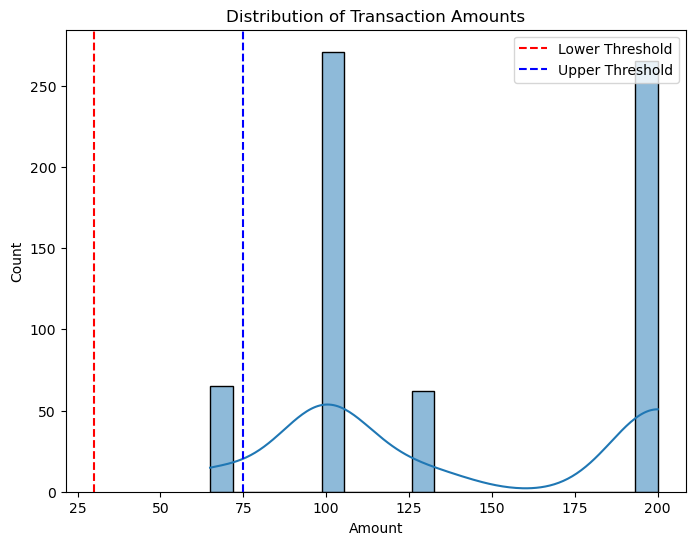

In [45]:
# We use the pyplot and seaborn libraries to visualize the data, refer to Cheatsheet Week 1 - Libraries and Exploring a dataset
import matplotlib.pyplot as plt
import seaborn as sns

# Analyzing transaction values for outliers
# Define thresholds based on typical transaction ranges
threshold_lower = 30  # Assumed based on knowledge from document
threshold_upper = 75

# Group transactions to see the distribution
grouped = sal.groupby(['Product ID'])['Amount'].describe()
print("\nTransaction summary by Product ID:")
print(grouped)

# Plot histogram for transaction values
plt.figure(figsize=(8, 6))
sns.histplot(sal['Amount'], bins=20, kde=True)
plt.axvline(threshold_lower, color='red', linestyle='--', label='Lower Threshold')
plt.axvline(threshold_upper, color='blue', linestyle='--', label='Upper Threshold')
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Amount')
plt.legend()
plt.show()

A total check (possibly at journal level) where the auditor compares the total of all debit amounts with the total of all credit amounts. A difference between these totals often indicates an incomplete dataset, which may be caused by an incomplete download or a problem during data import.

In [10]:
# Calculate the total of debit and credit amounts
total_debit = gl_df[gl_df['Debit/Credit'] == 'Debit']['Amount'].sum()
total_credit = gl_df[gl_df['Debit/Credit'] == 'Credit']['Amount'].sum()

# Check for differences
if total_debit != total_credit:
    print(f"Difference detected: Debit Total = {total_debit}, Credit Total = {total_credit}")
else:
    print("No differences detected between Debit and Credit totals.")

No differences detected between Debit and Credit totals.


An integrity check on the data to look for possible issues that may impact future analyses. For example: (1) checking for missing values, (2) ensuring consistency in specific fields (such as the number of digits in an account number or checking start and end dates within an entry), or (3) ensuring the presence of unique keys for linking files later.

In [12]:
# Check for missing values
missing_values = gl_df.isnull().sum()
print("Missing values per column:\n", missing_values)

Missing values per column:
 Unnamed: 0          0
Date                0
Description         0
Journal             0
Account             0
Debit/Credit        0
Amount              0
Product ID       4454
User              204
Relation_id      2235
Relation_name    2235
Period              0
AmountNet           0
dtype: int64
Relation_id column has unique keys: False


A reconciliation between the activity per general ledger account in the ledger and the calculated activity based on the summary generated by the client at the time of download. This activity is calculated by subtracting the opening balance from the closing balance for each account. Similar to step 1, any difference may be due to an incomplete download or a data import issue.

In [25]:
# Step 1: Calculate the opening balance for each GL account (Period 0) and replace NaNs with 0
gl_opening_balance = gl_df[gl_df['Period'] == 0]
opening_balance = gl_opening_balance.groupby('Account')['Amount'].sum().fillna(0)

# Step 2: Calculate the total debits for each GL account and replace NaNs with 0
debit = gl_df[gl_df['Debit/Credit'] == 'Debit'].groupby('Account')['Amount'].sum().fillna(0)

# Step 3: Calculate the total credits for each GL account and replace NaNs with 0
credit = gl_df[gl_df['Debit/Credit'] == 'Credit'].groupby('Account')['Amount'].sum().fillna(0)

# Step 4: Calculate the closing balance for each GL account
closing_balance = opening_balance + debit - credit

# Step 5: Compile a summary DataFrame with open, debit, credit, and close columns, grouped by GL account
gl_summary = pd.DataFrame({
    'open': opening_balance,
    'debit': debit,
    'credit': credit,
    'close': closing_balance
}).fillna(0)  # Fill any remaining NaNs with 0, just in case

# Display the summary table
gl_summary

,open,debit,credit,close
Account,,,,
1000 Cash,0.0,679608.60,885610.68,0.0
1100 Debtors,0.0,679608.60,679608.60,0.0
1300 Creditors,0.0,885610.68,885610.68,0.0
2100 VAT Recoverable,0.0,153701.04,0.00,0.0
2110 VAT Payable,0.0,0.00,117948.60,0.0
4000 Purchases,0.0,731909.64,0.00,0.0
4100 Rent Expense,0.0,14400.00,0.00,0.0
4200 Accounting and Audit Fees,0.0,120000.00,0.00,0.0
4201 Utilities,0.0,960.00,0.00,0.0


In [ ]:
# Write the summary table to an Excel file for reconciliation
gl_summary.to_excel("gl_summary.xlsx")

Conclusie:

## Analyse 1 Grootboeken in het Verkoopdagboek
* De accountant maakt een draaitabel met grootboeken (rijen), dagboeken (kolommen) en EUR-bedrag (waarden);
* De accountant verifieert dat de omzetboekingen op ‘8000 Omzet
digitale muziek’ en ‘8001 Omzet vinyl’ alleen in het verkoopdagboek
voorkomen (in de andere kolommen (dagboeken) is geen bedrag
opgenomen op deze grootboekregels;



Analyse 2 Debet en creditboekingen in omzetgrootboeken
• De accountant filtert de draaitabel op de grootboeken ‘8000 Omzet
digitale muziek’ en ‘8001 Omzet vinyl’ en splitst de kolommen in debet
en creditboekingen.
Voorbeeld van output
Analyse 1 Grootboeken in het Verkoopdagboek
De accountant constateert:
• Omzet wordt alleen via het verkoopdagboek verantwoord (conform
verwachting);
• In het verkoopdagboek worden alleen vooruit ontvangen bedragen, af
te dragen BTW en omzet verantwoord (conform verwachting);
• De af te dragen BTW van EUR 68.527 is 21% van de geboekte EUR
326.320 omzet digitale muziek en omzet vinyl (conform verwachting);
• De ingehouden BTW wordt via het BTW-dagboek afgewikkeld.
De boekingsgang is conform verwachting.